In [23]:
import os
import re
from collections import defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import nltk
import pymorphy3
import spacy
from nltk.tokenize import sent_tokenize

In [24]:
nltk.download('punkt')

try:
    nlp = spacy.load('ru_core_news_sm')
except OSError:
    from spacy.cli import download

    download('ru_core_news_sm')
    nlp = spacy.load('ru_core_news_sm')

morph = pymorphy3.MorphAnalyzer()

functional_pos = {
    'ADP',  # предлоги и постпозиции
    'AUX',  # вспомогательные глаголы
    'CONJ',  # союзы
    'DET',  # детерминативы
    'INTJ',  # междометия
    'PART',  # частицы
    'PRON',  # местоимения
    'PUNCT',  # знаки препинания
    'SYM',  # символы
    'X',  # прочие
}

exceptions = {'не'}
significant_pos = {'NOUN', 'VERB', 'ADJ', 'ADV'}


[nltk_data] Downloading package punkt to /Users/zeto/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [25]:
def load_reviews_from_directory(directory_path):
    reviews_data = {}
    for filename in os.listdir(directory_path):
        if filename.endswith('.txt'):
            product_name = os.path.splitext(filename)[0]
            file_path = os.path.join(directory_path, filename)
            with open(file_path, 'r', encoding='utf-8') as file:
                reviews = [line.strip() for line in file if line.strip()]
                reviews_data[product_name] = reviews
    return reviews_data


def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r"@[A-Za-z0-9_]+", '', text)
    text = re.sub(r"#\S+", '', text)
    text = re.sub(r"[^а-яА-Яa-zA-Z0-9\s.,!?;:]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def split_into_sentences(text):
    sentences = []
    for line in text.split('\n'):
        line = line.strip()
        if line:
            sentences.extend(sent_tokenize(line, language='russian'))
    return sentences

def parse_sentence(sentence):
    doc = nlp(sentence)
    dependencies = []
    lemmas = []
    
    for token in doc:
        # Фильтрация только значимых частей речи
        if (token.pos_ in significant_pos) or (token.text.lower() in exceptions):
            parsed = morph.parse(token.text)[0]
            lemma = parsed.normal_form
            lemmas.append(lemma)
            if token.dep_ != 'ROOT':
                head = token.head
                if (head.pos_ in significant_pos) or (head.text.lower() in exceptions):
                    head_parsed = morph.parse(head.text)[0]
                    head_lemma = head_parsed.normal_form
                    dependencies.append((head_lemma, lemma))
                else:
                    dependencies.append((head.text.lower(), lemma))
            else:
                dependencies.append(('ROOT', lemma))
    
    return dependencies, lemmas



def create_graph_from_dependencies(all_dependencies):
    G = nx.Graph()
    vertex_freq = defaultdict(int)
    edge_freq = defaultdict(int)

    for head, dependent in all_dependencies:
        if head != 'ROOT':
            vertex_freq[head] += 1
            vertex_freq[dependent] += 1
            sorted_pair = tuple(sorted([head, dependent]))
            edge_freq[sorted_pair] += 1
        else:
            vertex_freq[dependent] += 1

    for lemma, freq in vertex_freq.items():
        G.add_node(lemma, weight=freq)

    for (lemma1, lemma2), freq in edge_freq.items():
        G.add_edge(lemma1, lemma2, weight=freq)

    return G, vertex_freq, edge_freq


def visualize_graph(G, title="Граф слов и их связей из отзывов"):
    plt.figure(figsize=(15, 15))
    pos = nx.spring_layout(G, k=0.15, iterations=20)

    node_sizes = [data['weight'] * 100 for _, data in G.nodes(data=True)]
    edge_widths = [data['weight'] for _, _, data in G.edges(data=True)]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.7)
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.5)
    nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif')

    plt.title(title, fontsize=20)
    plt.axis('off')
    plt.show()


def visualize_filtered_graph(G, vertex_freq, min_node_freq=3, min_edge_weight=2, top_n=100, title="Фильтрованный граф", k=0.5):
    """
    Визуализация фильтрованного графа с учетом минимальной частоты узлов и ребер.
    """
    # Фильтрация узлов по минимальной частоте
    filtered_nodes = {node: freq for node, freq in vertex_freq.items() if freq >= min_node_freq}
    sorted_nodes = sorted(filtered_nodes.items(), key=lambda x: x[1], reverse=True)[:top_n]
    top_nodes = {node for node, _ in sorted_nodes}
    
    # Фильтрация ребер по минимальной частоте и наличию обоих узлов в top_nodes
    filtered_edges = [
        (u, v, data) for u, v, data in G.edges(data=True) 
        if data['weight'] >= min_edge_weight and u in top_nodes and v in top_nodes
    ]
    
    # Создание нового графа с отфильтрованными узлами и ребрами
    G_filtered = nx.Graph()
    for node in top_nodes:
        G_filtered.add_node(node, weight=vertex_freq[node])
    for u, v, data in filtered_edges:
        G_filtered.add_edge(u, v, weight=data['weight'])
    
    plt.figure(figsize=(15, 15))
    
    # Использование spring_layout с увеличенным параметром k
    pos = nx.spring_layout(G_filtered, k=k, iterations=50)  # Увеличьте значение k для увеличения расстояния между узлами
    
    # Определение размеров узлов и толщины ребер на основе весов
    node_sizes = [G_filtered.nodes[node]['weight'] * 300 for node in G_filtered]
    edge_widths = [data['weight'] for _, _, data in G_filtered.edges(data=True)]
    
    # Рисование узлов
    nx.draw_networkx_nodes(G_filtered, pos, node_size=node_sizes, node_color='orange', alpha=0.7)
    # Рисование ребер
    nx.draw_networkx_edges(G_filtered, pos, width=edge_widths, alpha=0.6)
    # Рисование подписей узлов
    nx.draw_networkx_labels(G_filtered, pos, font_size=10, font_family='sans-serif')
    
    plt.title(title, fontsize=20)
    plt.axis('off')
    plt.show()



def visualize_syntax_tree(dependencies, title="Синтаксическое дерево предложения"):
    G = nx.DiGraph()

    for head, dependent in dependencies:
        if head == 'ROOT':
            G.add_node(dependent, label=dependent)
        else:
            G.add_edge(head, dependent)

    plt.figure(figsize=(12, 8))
    try:
        pos = nx.nx_pydot.graphviz_layout(G, prog='dot')
    except Exception as e:
        print(f"Ошибка при построении расположения графа: {e}")
        return

    nx.draw(
        G, pos, with_labels=True, arrows=True, node_size=2000, node_color='lightgreen', font_size=10, font_weight='bold'
    )

    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()


Очистленные предложения (первые 5):
Долго думала нужен он мне или нет.Ритм жизни подтолкнул на покупку.Поларис фирма вообще очень нравится,много чего этой фирмы.После двух недель пользования,задаю себе вопрос,почему раньше не купила.Очень понравился пылесос.Рекомендую однозначно.
очень понравился отличный помощник рекомендую
Отличный робот.
Выгребвет пыль даже из под шкафов и холодильника.
Тихо работает.

Леммы предложений (первые 5):
['долго', 'думать', 'нужный', 'ритм', 'жизнь', 'подтолкнуть', 'покупка', 'фирма', 'вообще', 'очень', 'нравиться', 'много', 'фирма', 'неделя', 'пользование', 'задавать', 'вопрос', 'почему', 'ранний', 'не', 'купить', 'очень', 'понравиться', 'пылесос', 'рекомендовать', 'однозначно']
['очень', 'понравиться', 'отличный', 'помощник', 'рекомендовать']
['отличный', 'робот']
['выгребвет', 'пыль', 'шкаф', 'холодильник']
['тихо', 'работать']

Синтаксические деревья для первых 3 предложений:

Предложение: Долго думала нужен он мне или нет.Ритм жизни подтолкнул на по

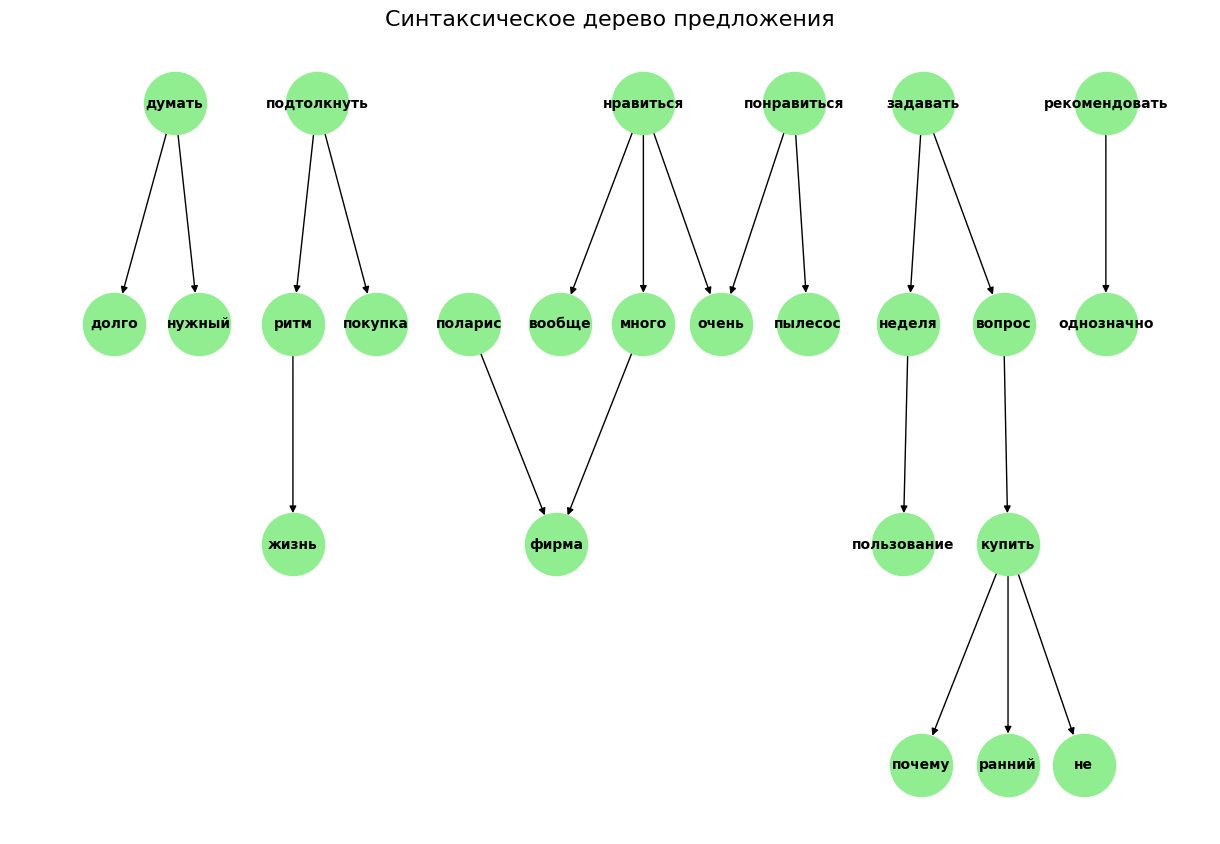


Предложение: очень понравился отличный помощник рекомендую


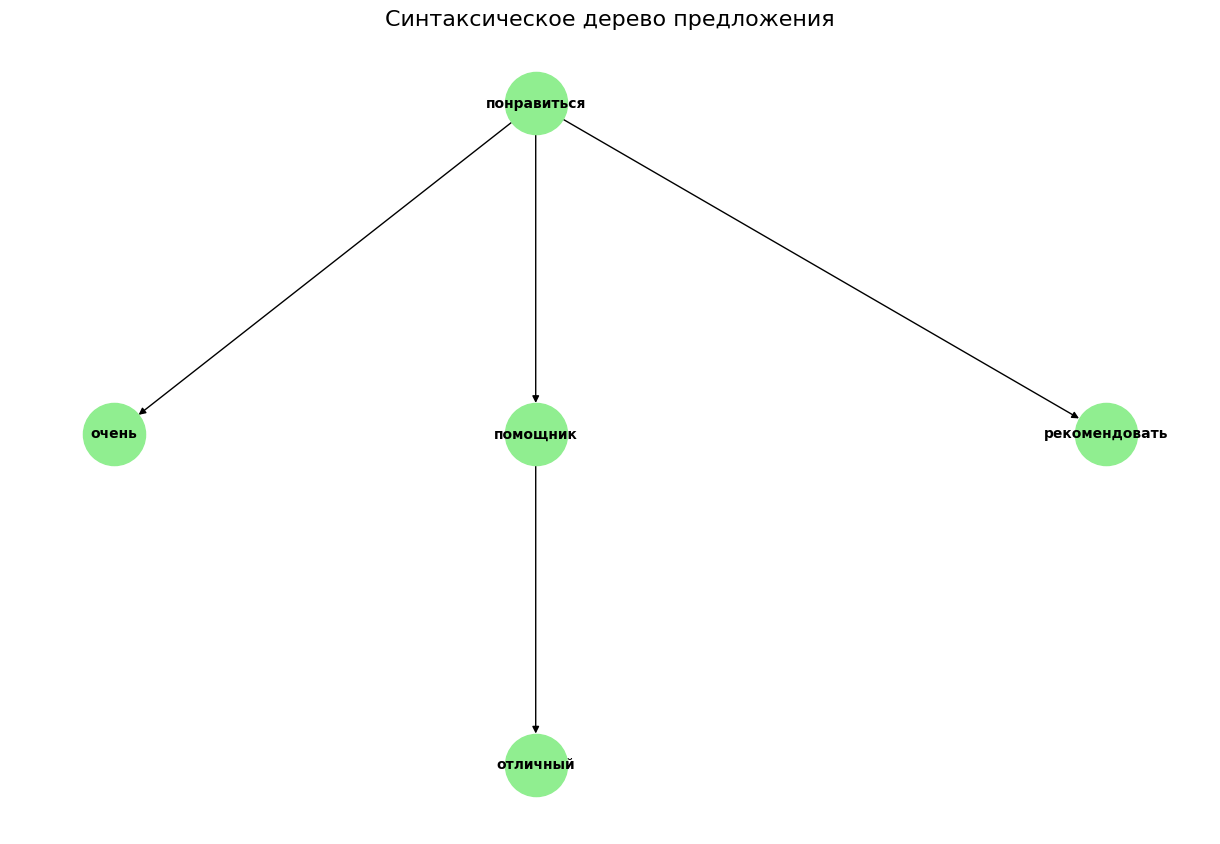


Предложение: Отличный робот.


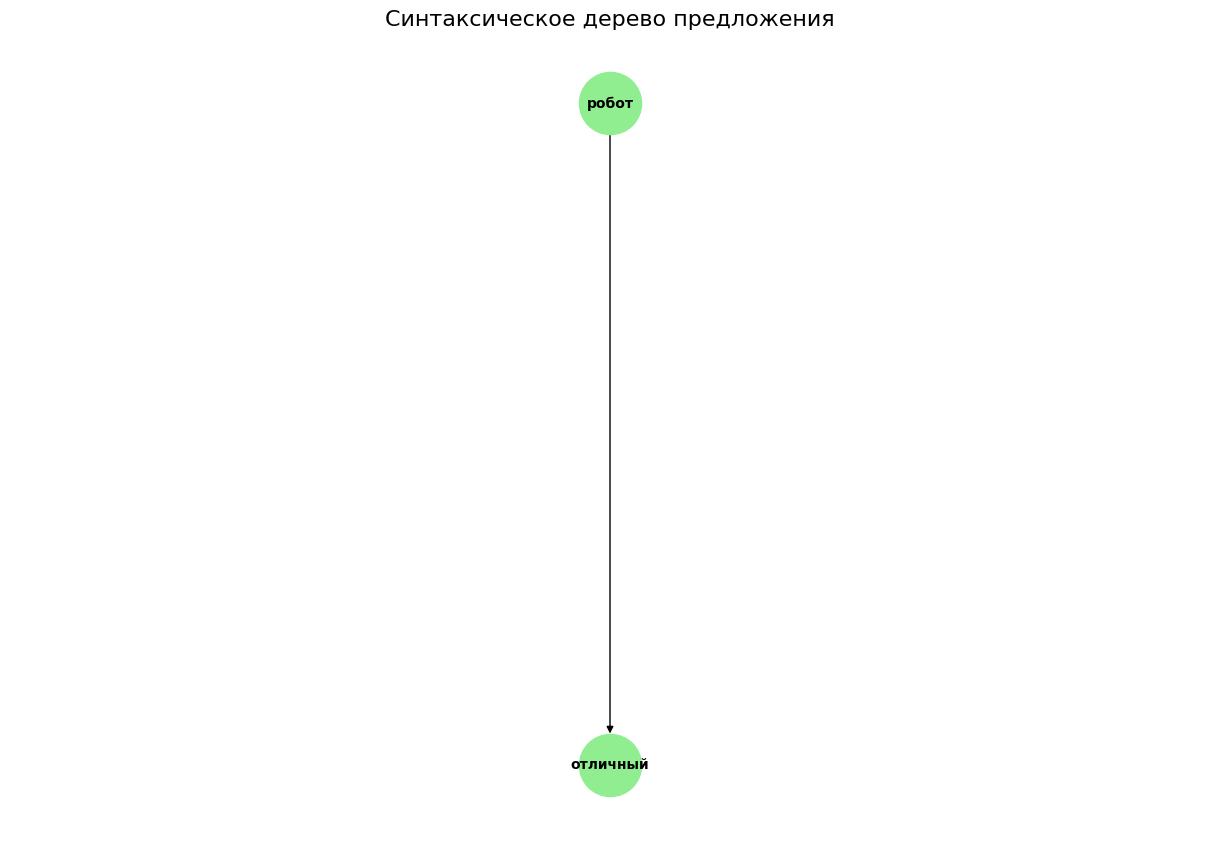


Общий граф: 3054 узлов, 10301 ребер


In [26]:
directory_path = 'reviews/'
reviews_data = load_reviews_from_directory(directory_path)

# all_reviews = reviews_data['gel_929']
# all_reviews = reviews_data['iphone_723']
all_reviews = reviews_data['robot_pylesos_4665']

cleaned_sentences = []
for text in all_reviews:
    cleaned = clean_text(text)
    sentences = split_into_sentences(cleaned)
    cleaned_sentences.extend(sentences)

print("\nОчистленные предложения (первые 5):")
for sentence in cleaned_sentences[:5]:
    print(sentence)

all_dependencies = []
lemmatized_sentences = []
for sentence in cleaned_sentences:
    dependencies, lemmas = parse_sentence(sentence)
    all_dependencies.extend(dependencies)
    lemmatized_sentences.append(lemmas)

print("\nЛеммы предложений (первые 5):")
for lemma in lemmatized_sentences[:5]:
    print(lemma)

print("\nСинтаксические деревья для первых 3 предложений:")
for sentence in cleaned_sentences[:3]:
    dependencies, _ = parse_sentence(sentence)
    print(f"\nПредложение: {sentence}")
    visualize_syntax_tree(dependencies)

G, vertex_freq, edge_freq = create_graph_from_dependencies(all_dependencies)
print(f"\nОбщий граф: {G.number_of_nodes()} узлов, {G.number_of_edges()} ребер")

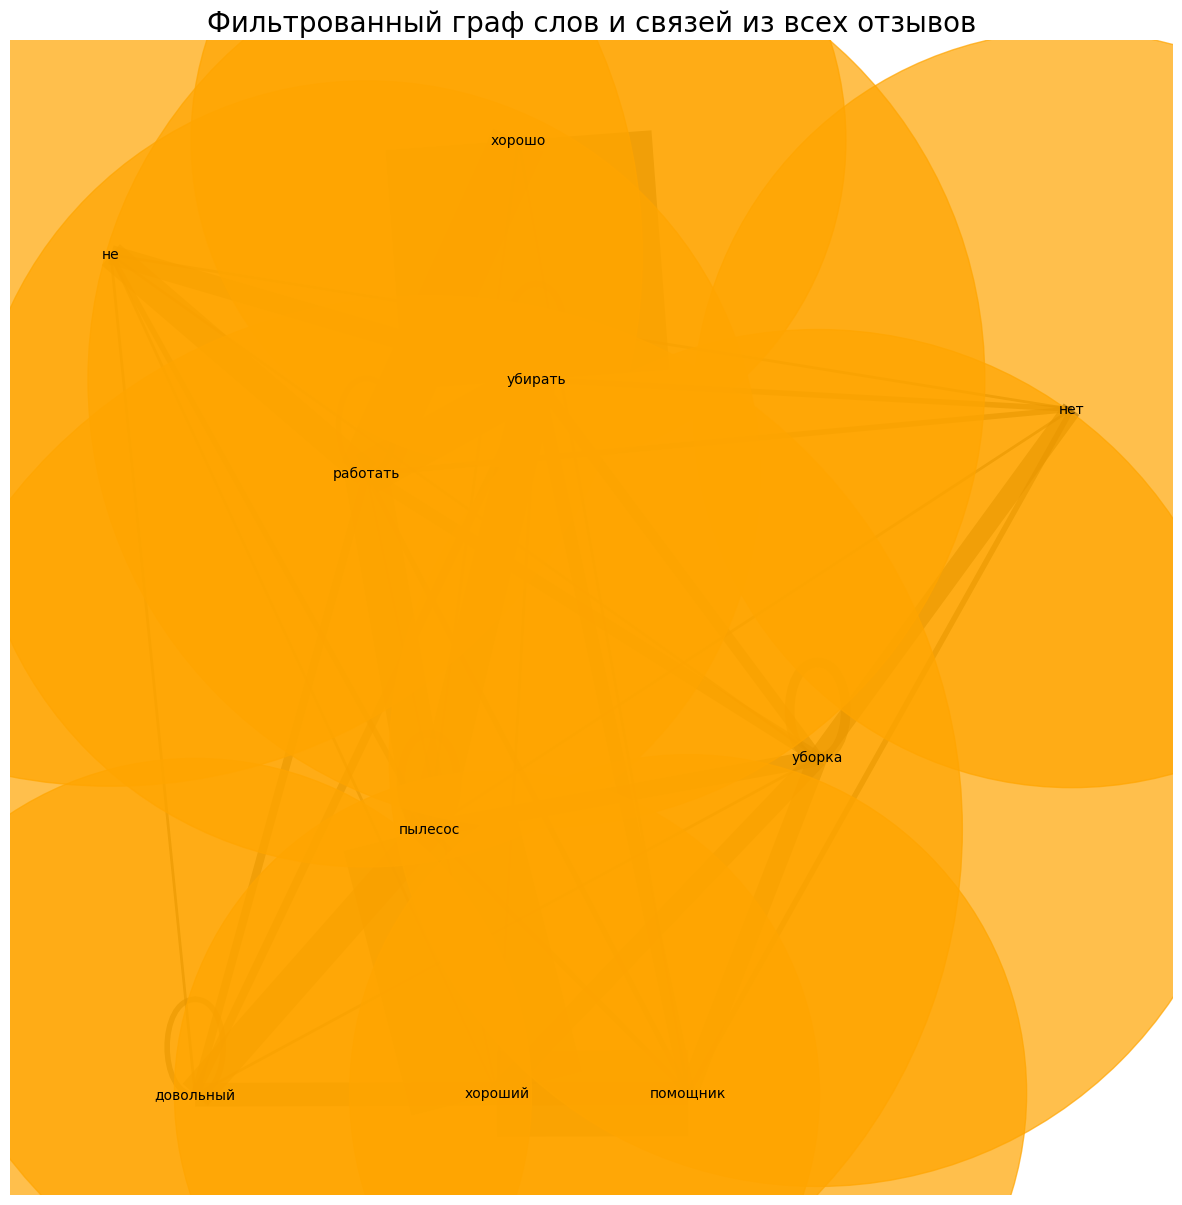

In [30]:
visualize_filtered_graph(G, vertex_freq, min_node_freq=3, min_edge_weight=2, top_n=10, k=1, title="Фильтрованный граф слов и связей из всех отзывов")